In [1]:
%load_ext autoreload
%autoreload 2
import sys
from rdkit import Chem
sys.path.append('src')


In [2]:
from src.visualization.molecule_renderer import MoleculeRenderer

def draw_mol(mol, title="", highlight_atoms=None, highlight_bonds=None, display_props=None):
    mr = MoleculeRenderer()
    display(mr.render_2d(mol, title, highlight_atoms, highlight_bonds, display_props))


In [3]:
print("\n=== Тестирование _find_connection_points ===")

def create_test_molecule_with_connection_points():
    """Создаем тестовую молекулу с разными типами точек соединения"""
    smiles = "CCOC(C)=O"  # Этилацетат
    mol = Chem.MolFromSmiles(smiles)

    # Устанавливаем свойства connection_type для разных атомов
    # Атом 0 - to_core
    mol.GetAtomWithIdx(0).SetProp("connection_type", "to_core")
    # Атом 2 - to_branch
    mol.GetAtomWithIdx(2).SetProp("connection_type", "to_branch")
    # Атом 4 - to_core
    mol.GetAtomWithIdx(4).SetProp("connection_type", "to_core")
    # Атом 5 - to_branch
    mol.GetAtomWithIdx(5).SetProp("connection_type", "to_branch")

    return mol

def test_find_connection_points_basic():
    """Базовый тест поиска точек соединения"""
    print("=== Базовый тест ===")

    mol = create_test_molecule_with_connection_points()
    draw_mol(mol, "Тестовая молекула", display_props=["connection_type"])

    # Тестируем метод
    connection_points = _find_connection_points(mol, "to_core")
    print(f"to_core точки: {connection_points}")

    connection_points = _find_connection_points(mol, "to_branch")
    print(f"to_branch точки: {connection_points}")

    # Проверяем результаты
    expected_core = [0, 4]
    expected_branch = [2, 5]

    if set(connection_points) == set(expected_branch):
        print("✓ Базовый тест пройден")
    else:
        print(f"✗ Ошибка: ожидалось {expected_branch}, получено {connection_points}")

    return mol

def test_find_connection_points_no_matches():
    """Тест когда нет точек соединения указанного типа"""
    print("\n=== Тест отсутствия совпадений ===")

    mol = create_test_molecule_with_connection_points()

    # Ищем несуществующий тип
    connection_points = _find_connection_points(mol, "nonexistent_type")
    print(f"nonexistent_type точки: {connection_points}")

    if connection_points == []:
        print("✓ Тест отсутствия совпадений пройден")
    else:
        print(f"✗ Ошибка: ожидалось [], получено {connection_points}")

def test_find_connection_points_mixed_properties():
    """Тест со смешанными свойствами атомов"""
    print("\n=== Тест смешанных свойств ===")

    smiles = "CCCC"
    mol = Chem.MolFromSmiles(smiles)

    # Устанавливаем разные свойства
    mol.GetAtomWithIdx(0).SetProp("connection_type", "to_core")
    mol.GetAtomWithIdx(1).SetProp("other_property", "some_value")  # Другое свойство
    mol.GetAtomWithIdx(2).SetProp("connection_type", "to_branch")
    # Атом 3 без свойства connection_type

    draw_mol(mol, "Молекула со смешанными свойствами", display_props=["connection_type"])

    core_points = _find_connection_points(mol, "to_core")
    branch_points = _find_connection_points(mol, "to_branch")

    print(f"to_core точки: {core_points}")
    print(f"to_branch точки: {branch_points}")

    if core_points == [0] and branch_points == [2]:
        print("✓ Тест смешанных свойств пройден")
    else:
        print(f"✗ Ошибка: ожидалось core=[0], branch=[2], получено core={core_points}, branch={branch_points}")

def test_find_connection_points_empty_molecule():
    """Тест с пустой молекулой"""
    print("\n=== Тест пустой молекулы ===")

    mol = Chem.MolFromSmiles("")

    connection_points = _find_connection_points(mol, "to_core")
    print(f"Пустая молекула - to_core точки: {connection_points}")

    if connection_points == []:
        print("✓ Тест пустой молекулы пройден")
    else:
        print(f"✗ Ошибка: ожидалось [], получено {connection_points}")

def test_find_connection_points_case_sensitive():
    """Тест чувствительности к регистру"""
    print("\n=== Тест чувствительности к регистру ===")

    smiles = "CC"
    mol = Chem.MolFromSmiles(smiles)

    mol.GetAtomWithIdx(0).SetProp("connection_type", "to_branch")
    mol.GetAtomWithIdx(1).SetProp("connection_type", "TO_BRANCH")  # Верхний регистр

    draw_mol(mol, "Тест регистра", display_props=["connection_type"])

    lower_result = _find_connection_points(mol, "to_branch")
    upper_result = _find_connection_points(mol, "TO_BRANCH")

    print(f"to_branch точки: {lower_result}")
    print(f"TO_BRANCH точки: {upper_result}")

    if lower_result == [0] and upper_result == [1]:
        print("✓ Тест чувствительности к регистру пройден")
    else:
        print(f"✗ Ошибка: ожидалось lower=[0], upper=[1], получено lower={lower_result}, upper={upper_result}")

def test_find_connection_points_complex_molecule():
    """Тест на сложной молекуле"""
    print("\n=== Тест сложной молекулы ===")

    # Создаем сложную молекулу (бензол с заместителями)
    smiles = "c1ccccc1CCO"
    mol = Chem.MolFromSmiles(smiles)

    # Устанавливаем точки соединения в разных частях молекулы
    mol.GetAtomWithIdx(0).SetProp("connection_type", "to_branch")  # Атом в кольце
    mol.GetAtomWithIdx(6).SetProp("connection_type", "to_core")    # Углерод метильной группы
    mol.GetAtomWithIdx(7).SetProp("connection_type", "to_branch")  # Кислород

    draw_mol(mol, "Сложная молекула", display_props=["connection_type"])

    core_points = _find_connection_points(mol, "to_core")
    branch_points = _find_connection_points(mol, "to_branch")

    print(f"to_core точки: {core_points}")
    print(f"to_branch точки: {branch_points}")

    if core_points == [6] and set(branch_points) == {0, 7}:
        print("✓ Тест сложной молекулы пройден")
    else:
        print(f"✗ Ошибка: ожидалось core=[6], branch=[0,7], получено core={core_points}, branch={branch_points}")

# Вспомогательная функция для тестирования (копия метода из класса)
def _find_connection_points(mol, connection_type):
    """Find atoms with specified connection type."""
    connection_points = []
    for atom in mol.GetAtoms():
        if (atom.HasProp("connection_type") and
                atom.GetProp("connection_type") == connection_type):
            connection_points.append(atom.GetIdx())
    return connection_points



=== Тестирование _find_connection_points ===


ЗАПУСК ВСЕХ ТЕСТОВ _find_connection_points
=== Базовый тест ===


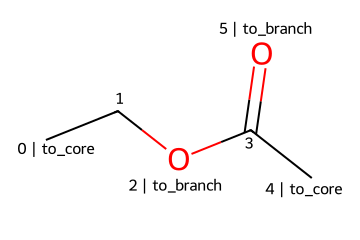

to_core точки: [0, 4]
to_branch точки: [2, 5]
✓ Базовый тест пройден

=== Тест отсутствия совпадений ===
nonexistent_type точки: []
✓ Тест отсутствия совпадений пройден

=== Тест смешанных свойств ===


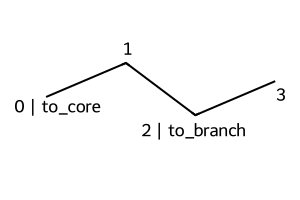

to_core точки: [0]
to_branch точки: [2]
✓ Тест смешанных свойств пройден

=== Тест пустой молекулы ===
Пустая молекула - to_core точки: []
✓ Тест пустой молекулы пройден

=== Тест чувствительности к регистру ===


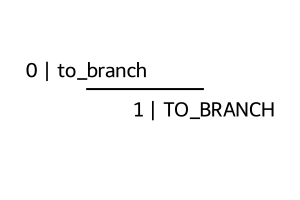

to_branch точки: [0]
TO_BRANCH точки: [1]
✓ Тест чувствительности к регистру пройден

=== Тест сложной молекулы ===


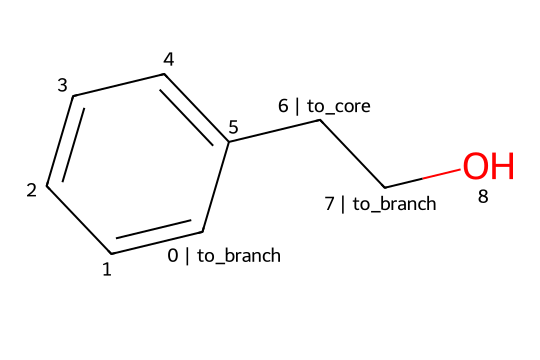

to_core точки: [6]
to_branch точки: [0, 7]
✓ Тест сложной молекулы пройден

ВСЕ ТЕСТЫ ЗАВЕРШЕНЫ


In [4]:
# Запуск всех тестов
print("ЗАПУСК ВСЕХ ТЕСТОВ _find_connection_points")
print("=" * 50)

test_mol = test_find_connection_points_basic()
test_find_connection_points_no_matches()
test_find_connection_points_mixed_properties()
test_find_connection_points_empty_molecule()
test_find_connection_points_case_sensitive()
test_find_connection_points_complex_molecule()

print("\n" + "=" * 50)
print("ВСЕ ТЕСТЫ ЗАВЕРШЕНЫ")



=== Интеграционный тест ===
Core фрагмент:


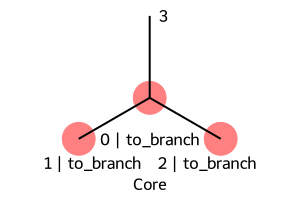

Точки соединения to_branch в core: [0, 1, 2]

Branch фрагмент:


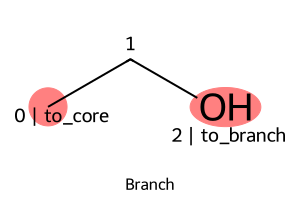

Точки соединения to_core в branch: [0]
Точки соединения to_branch в branch: [2]
✓ Интеграционный тест пройден - точки соединения найдены


In [5]:
# Дополнительный тест - интеграция с реальным сценарием
print("\n=== Интеграционный тест ===")

def create_dendrimer_fragments():
    """Создаем фрагменты для дендримера"""

    # Core фрагмент
    core_smiles = "C(C)(C)C"  # Неопентан-like структура
    core_mol = Chem.MolFromSmiles(core_smiles)
    core_mol.GetAtomWithIdx(0).SetProp("connection_type", "to_branch")
    core_mol.GetAtomWithIdx(1).SetProp("connection_type", "to_branch")
    core_mol.GetAtomWithIdx(2).SetProp("connection_type", "to_branch")

    # Branch фрагмент
    branch_smiles = "CCO"
    branch_mol = Chem.MolFromSmiles(branch_smiles)
    branch_mol.GetAtomWithIdx(0).SetProp("connection_type", "to_core")
    branch_mol.GetAtomWithIdx(2).SetProp("connection_type", "to_branch")

    return core_mol, branch_mol

core, branch = create_dendrimer_fragments()

print("Core фрагмент:")
core_points = _find_connection_points(core, "to_branch")
draw_mol(core, "Core", highlight_atoms=core_points, display_props=["connection_type"])
print(f"Точки соединения to_branch в core: {core_points}")

print("\nBranch фрагмент:")
branch_core_points = _find_connection_points(branch, "to_core")
branch_branch_points = _find_connection_points(branch, "to_branch")
draw_mol(branch, "Branch", highlight_atoms=branch_core_points + branch_branch_points, display_props=["connection_type"])
print(f"Точки соединения to_core в branch: {branch_core_points}")
print(f"Точки соединения to_branch в branch: {branch_branch_points}")

# Проверяем что можем найти точки для соединения
if core_points and branch_core_points:
    print("✓ Интеграционный тест пройден - точки соединения найдены")
else:
    print("✗ Ошибка интеграционного теста")